# 14. 기간구조 내재변동성으로 MC 재산출 — 오차가 줄어드는가

`1_MC_recompute` 의 MC 는 **180일 역사변동성(HV)** 을 쓴다. 공정가보다 평균 약 556원 비싸게 나오는데
(과대평가), 노트북 1은 그 원인을 "역사변동성이 하방 스큐와 미래 변동성을 담지 못하는 구조적 편향" 으로 본다.
여기서는 변동성 입력을 **옵션 내재변동성 + 기간구조** 로 바꿔 같은 그림을 다시 뽑는다.

## 방법

보유 IV 는 기초자산별 **단일 만기 ATM IV** 뿐이다 (`data/raw/iv_daily_atm`, 만기·행사가 차원 없음).
Jiang-Tian 의 모형독립 분산은 행사가 전 구간 옵션가가 필요하므로 적용할 재료가 없다. 그래서
**공표 변동성지수에서 기간구조 형태만 차용**한다.

    σ_udl(T) = ATM_udl · σ_VIX(T) / σ_VIX(30일)

σ_VIX(T) 는 같은 날 VIX9D·VIX·VIX3M·VIX6M(9·30·93·182일)의 **총분산** `w(T)=σ²(T)·T` 에서 읽는다.
노드 사이는 **w 에 대해 선형보간** (IV 를 보간하면 캘린더 차익 부재가 깨진다), 182일 이후는 마지막 구간
기울기로 선형 외삽(= 선도분산 일정). ELS 만기 대부분이 3년이라 항상 외삽 구간이다. 구현은 `module/iv_term.py`.

## 변형 — 효과를 분리하려고 4개를 나란히 본다

| 변형 | 변동성 | 비교하면 |
|---|---|---|
| **HV** | 180일 역사변동성 (정본 `mc`) | 기준선 |
| **A0** | ATM IV 수준, 기간구조 없음 | `A0 − HV` = **수준 효과** |
| **A** | ATM IV × 기간구조 비율 | `A − A0` = **기간구조 효과** |
| **B** | A 와 같되 유로스톡스50 만 HV 수준 | `A − B` = **대용치 효과** |

**대용치 문제**: 원천에 유로스톡스50(`.STOXX50E`)이 없어 **STOXX Europe 50**(`.STOXX50`)으로 매핑돼 있다.
영국·스위스 방어주가 섞인 다른 지수라 IV 가 HV 보다 평균 2.8%p 낮다. 상품의 85.8% 가 이 기초자산을 쓴다.

## 공통난수 — 변동성만 다르게

정본 `mc` 와 같은 엔진·NS 할인·180일 상관·**40,000 경로·같은 시드(mc_seed)** 로 가격했다. HV 벡터를 넣으면
정본 `mc` 를 **오차 0.00원으로 비트 단위 재현**한다(300건 확인). 따라서 네 변형의 차이는 오직 변동성에서 온다.

> **한계 (자문 시 확인 필요)** — (1) 미국 S&P500 의 기간구조 형태를 유로·홍콩·한국·일본에 그대로 차용한다.
> (2) 6개월 이후는 시장자료가 아니라 외삽이다. (3) ATM 이라 하방 스큐는 담지 못한다. (4) 보유 ATM IV 의
> 만기를 30일로 가정했다(파일에 표기 없음; `.SPX` ATM 이 VIX9D·VIX 와 상관 0.83·0.82).


In [1]:
import glob
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from util import file_manager as fm, plot as _plot     # import 만으로 dpi400·투명·PPT 밴드

FACE = 10000
VAR = ["HV", "A0", "A", "B"]
LAB = {"HV": "HV 180d (current)", "A0": "ATM IV level only",
       "A": "ATM IV x term structure", "B": "A + EuroStoxx at HV level"}
COL = {"HV": "#9aa5ad", "A0": _plot._QUAL[0], "A": _plot._QUAL[2], "B": _plot._QUAL[3]}

base = pd.read_parquet(fm.source()).sort_values("isu_ord").reset_index(drop=True)
R = pd.concat([pd.read_parquet(p) for p in sorted(glob.glob(str(fm.CACHE / "mc_ivts" / "chunk_*.parquet")))],
              ignore_index=True).sort_values("i").set_index("i")
assert len(R) == len(base), f"재가격 결과 {len(R)} != 상품 {len(base)} (chunk 누락)"

d = base[["item", "isu_ord", "fair", "mc", "opt_type", "ki_yn"]].copy()
d["mc_HV"] = d["mc"]
for v in ["A0", "A", "B"]:
    d[f"mc_{v}"] = R[f"mc_{v}"].reindex(d.index)
    d[f"mc_{v}"] = d[f"mc_{v}"].fillna(d["mc"])          # IV 없어 안 바뀐 상품은 정본 값 그대로
d["status"] = R["status"].reindex(d.index)
d["n_iv"] = R["n_iv"].reindex(d.index).fillna(0).astype(int)
d["sx5e_iv"] = R["sx5e_iv"].reindex(d.index).fillna(0).astype(int)
d["ratio"] = R["ratio"].reindex(d.index)
d["changed"] = (R["unchanged"].reindex(d.index) == 0).fillna(False)
d["year"] = d.isu_ord.map(lambda o: pd.Timestamp.fromordinal(int(o)).year)
for v in VAR:
    d[f"err_{v}"] = (d.fair - d[f"mc_{v}"]) * FACE

print(f"상품 {len(d):,} | 상태 {d.status.value_counts().to_dict()}")
print(f"변동성이 실제로 바뀐 상품 {int(d.changed.sum()):,} ({d.changed.mean()*100:.1f}%)  "
      f"| IV 3자산 완비 {int((d.n_iv==3).sum()):,}  | 유로스톡스 IV 사용 {int(d.sx5e_iv.sum()):,}")
print(f"기간구조 비율 σ(T)/σ(30일): 평균 {d.ratio.mean():.3f}  중앙값 {d.ratio.median():.3f}  "
      f"범위 {d.ratio.min():.2f}~{d.ratio.max():.2f}")

상품 58,790 | 상태 {'ok': 58790}
변동성이 실제로 바뀐 상품 50,800 (86.4%)  | IV 3자산 완비 45,325  | 유로스톡스 IV 사용 43,251
기간구조 비율 σ(T)/σ(30일): 평균 1.295  중앙값 1.319  범위 0.48~1.82


## 14-1. 전체 요약 — 오차가 줄었는가

`공정가 − MC` 가 0 에 가까울수록 MC 가 공정가를 잘 맞춘 것이다. 음수는 MC 과대평가.
**전체**와 **변동성이 실제로 바뀐 상품만** 두 범위로 본다 (2015~16년 등 IV 가 없는 상품은 네 변형이 모두 같다).


In [2]:
from sklearn.metrics import r2_score


def summ(sub, scope):
    rows = []
    for v in VAR:
        e = sub[f"err_{v}"]
        rows.append({"scope": scope, "variant": v, "n": len(sub),
                     "mean_err_KRW": e.mean(), "median_err_KRW": e.median(),
                     "MAE_KRW": e.abs().mean(), "RMSE_KRW": np.sqrt((e**2).mean()),
                     "MAPE%": (e.abs() / (sub.fair*FACE)).mean()*100,
                     "R2": r2_score(sub.fair, sub[f"mc_{v}"])})
    return rows


S = pd.DataFrame(summ(d, "all") + summ(d[d.changed], "changed only")
                 + summ(d[d.n_iv == 3], "all 3 assets have IV"))
S.to_csv(fm.stat("mc_ivts_summary"), index=False)
for sc in S.scope.unique():
    t = S[S.scope == sc].set_index("variant")
    print(f"=== {sc}  (n={int(t.n.iloc[0]):,}) ===")
    print(t[["mean_err_KRW", "median_err_KRW", "MAE_KRW", "RMSE_KRW", "MAPE%", "R2"]].round(2).to_string())
    h = t.loc["HV"]
    for v in ["A0", "A", "B"]:
        print(f"   {v:3s} vs HV: 평균오차 {t.loc[v,'mean_err_KRW']-h.mean_err_KRW:+7.1f}원  "
              f"MAE {t.loc[v,'MAE_KRW']-h.MAE_KRW:+7.1f}원  R2 {t.loc[v,'R2']-h.R2:+.4f}")
    print()

=== all  (n=58,790) ===
         mean_err_KRW  median_err_KRW  MAE_KRW  RMSE_KRW  MAPE%    R2
variant                                                              
HV            -556.03         -568.90   613.69    725.22   6.78 -1.40
A0            -507.44         -555.84   671.88    827.56   7.41 -2.13
A             -249.99         -336.77   507.04    648.98   5.55 -0.92
B             -190.05         -283.01   476.86    621.89   5.20 -0.77
   A0  vs HV: 평균오차   +48.6원  MAE   +58.2원  R2 -0.7252
   A   vs HV: 평균오차  +306.0원  MAE  -106.6원  R2 +0.4782
   B   vs HV: 평균오차  +366.0원  MAE  -136.8원  R2 +0.6353

=== changed only  (n=50,800) ===
         mean_err_KRW  median_err_KRW  MAE_KRW  RMSE_KRW  MAPE%    R2
variant                                                              
HV            -572.37         -593.62   631.75    743.51   7.00 -1.41
A0            -516.14         -581.72   699.09    858.31   7.72 -2.21
A             -218.20         -314.49   508.32    656.93   5.56 -0.88
B         

## 14-2. 효과 분해 — 무엇이 오차를 움직였나

변동성이 바뀐 상품에서 MC 변화를 세 조각으로 나눈다. 공통난수라 각 조각이 순수하게 그 요인의 몫이다.


=== MC 변화 분해 (원, 음수 = MC 가 싸짐 = 과대평가 완화) ===
      level  (A0 - HV)  term structure  (A - A0)  EuroStoxx proxy  (B - A)  total  (B - HV)
mean             -56.2                    -297.9                     -69.4           -423.5
50%               10.0                    -271.4                     -31.0           -309.5
std              553.0                     420.8                     156.2            513.9
min            -5302.3                   -2380.1                   -1273.4          -6313.2
max             1902.3                    3047.0                    1103.5           1388.4


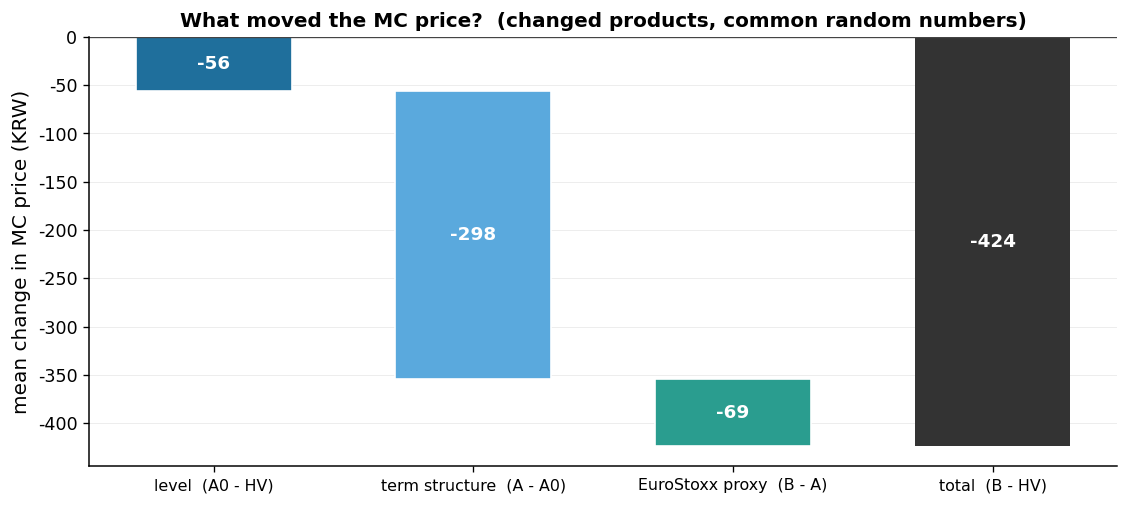

saved -> mc_ivts_decomposition.png


In [3]:
C = d[d.changed]
dec = pd.DataFrame({
    "level  (A0 - HV)": (C.mc_A0 - C.mc_HV) * FACE,
    "term structure  (A - A0)": (C.mc_A - C.mc_A0) * FACE,
    "EuroStoxx proxy  (B - A)": (C.mc_B - C.mc_A) * FACE,
})
dec["total  (B - HV)"] = dec.sum(axis=1)
print("=== MC 변화 분해 (원, 음수 = MC 가 싸짐 = 과대평가 완화) ===")
print(dec.describe().loc[["mean", "50%", "std", "min", "max"]].round(1).to_string())
dec.describe().to_csv(fm.stat("mc_ivts_decomposition"))

fig, ax = plt.subplots(figsize=(_plot.SLIDE_W*.72, 4.4))
m = dec.mean(); cum = 0
names = list(m.index[:-1])
for j, nm in enumerate(names):
    v = m[nm]
    ax.bar(j, v, bottom=cum, color=_plot._QUAL[j % 8], edgecolor="white", width=.6)
    ax.text(j, cum + v/2, f"{v:+.0f}", ha="center", va="center", fontsize=11, color="white",
            fontweight="bold")
    cum += v
ax.bar(len(names), m.iloc[-1], color="#333333", width=.6)
ax.text(len(names), m.iloc[-1]/2, f"{m.iloc[-1]:+.0f}", ha="center", va="center",
        fontsize=11, color="white", fontweight="bold")
ax.set_xticks(range(len(m))); ax.set_xticklabels(m.index, fontsize=9.5)
ax.axhline(0, color="#444", lw=.8)
ax.set_ylabel("mean change in MC price (KRW)")
ax.set_title("What moved the MC price?  (changed products, common random numbers)", fontsize=12)
ax.grid(axis="y", color="#dddddd", lw=.5, alpha=.6)
fig.tight_layout(); fig.savefig(fm.image("mc_ivts_decomposition")); plt.show()
print("saved ->", fm.image("mc_ivts_decomposition").name)

## 14-3. 노트북 1 그림 ① 재현 — `(공정가 − MC)` 히스토그램

`1_MC_recompute` 의 첫 그림과 같은 형식으로 네 변형을 겹친다.


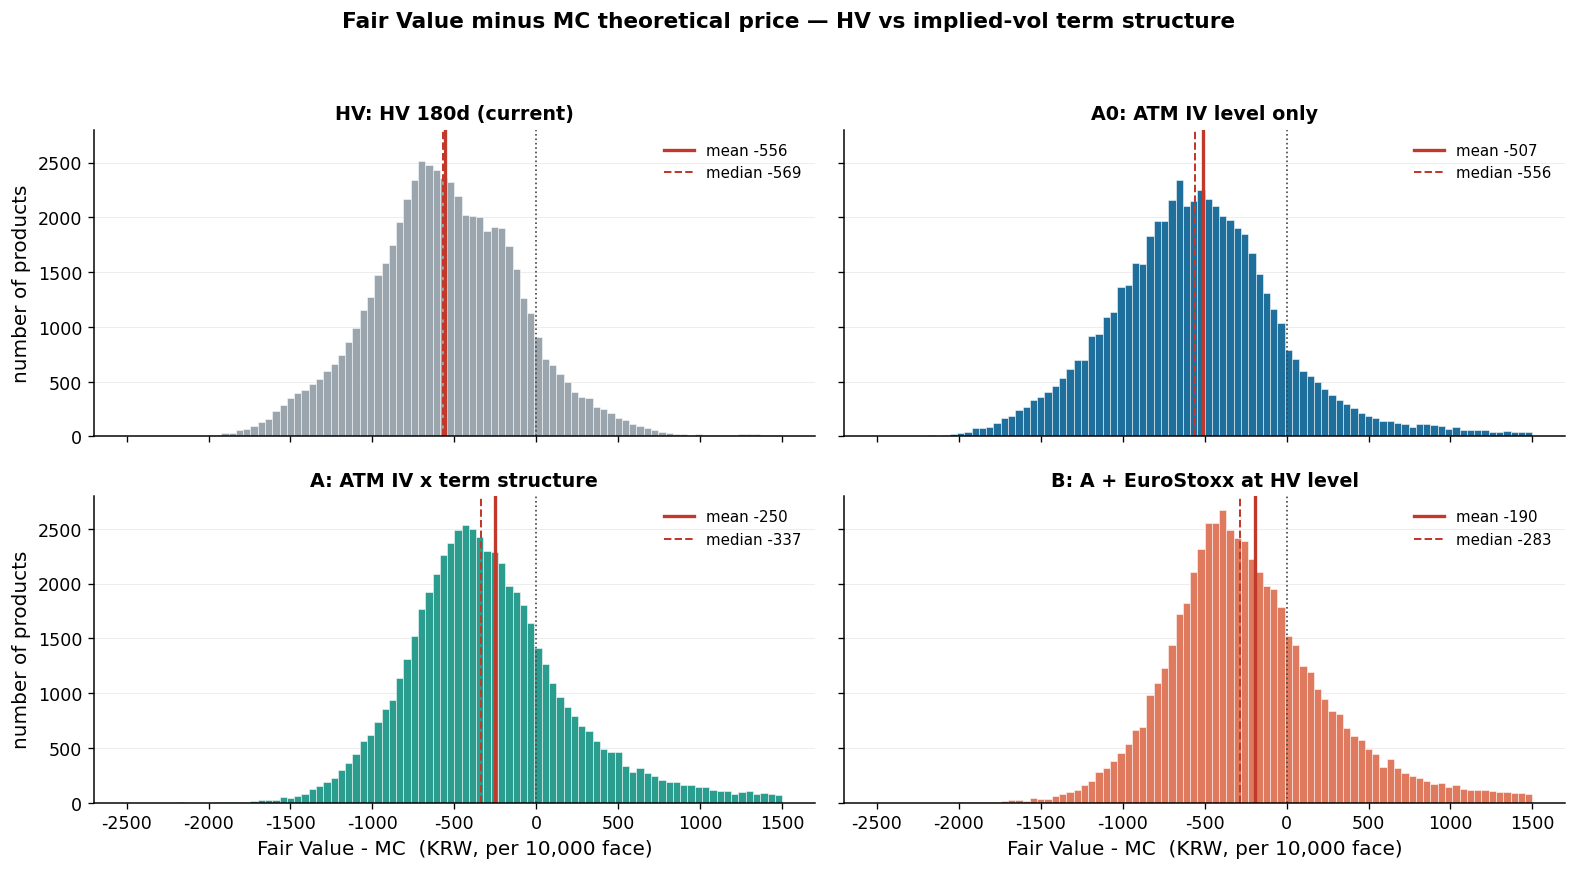

saved -> mc_ivts_hist.png


In [4]:
fig, axs = plt.subplots(2, 2, figsize=(_plot.SLIDE_W, 7.4), sharex=True, sharey=True)
bins = np.linspace(-2500, 1500, 91)
for a, v in zip(axs.ravel(), VAR):
    e = d[f"err_{v}"].dropna()
    a.hist(e, bins=bins, color=COL[v], edgecolor="white", linewidth=.3)
    a.axvline(e.mean(), color="#c0392b", lw=2, label=f"mean {e.mean():,.0f}")
    a.axvline(e.median(), color="#c0392b", lw=1.2, ls="--", label=f"median {e.median():,.0f}")
    a.axvline(0, color="#444", lw=1, ls=":")
    a.set_title(f"{v}: {LAB[v]}", fontsize=11.5)
    a.legend(fontsize=9); a.grid(axis="y", color="#dddddd", lw=.5, alpha=.6)
for a in axs[1]:
    a.set_xlabel("Fair Value - MC  (KRW, per 10,000 face)")
for a in axs[:, 0]:
    a.set_ylabel("number of products")
fig.suptitle("Fair Value minus MC theoretical price — HV vs implied-vol term structure",
             fontsize=13, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.95))
fig.savefig(fm.image("mc_ivts_hist")); plt.show()
print("saved ->", fm.image("mc_ivts_hist").name)

## 14-4. 노트북 1 그림 ② 재현 — 가격구간별 오차 · MAPE

노트북 1은 **저가(위험) 구간에서 MC 가 크게 과대평가**하는 것을 스큐의 흔적으로 봤다. 기간구조로 그 패턴이
평탄해지는지 본다. ATM 은 스큐를 담지 못하므로, 저가 구간이 남는다면 그 몫은 스큐다.


variant          HV      A0      A      B
seg                                      
0.699~0.884 -1004.0 -1113.0 -694.0 -560.0
0.884~0.912  -779.0  -783.0 -488.0 -408.0
0.912~0.933  -668.0  -580.0 -362.0 -317.0
0.933~0.953  -501.0  -419.0 -234.0 -199.0
0.953~0.976  -323.0  -208.0   19.0   58.0
0.976~1.050   -61.0    58.0  260.0  286.0

variant          HV      A0      A      B
seg                                      
0.699~0.884  12.516  13.591  8.804  7.647
0.884~0.912   9.213   9.532  6.597  6.069
0.912~0.933   7.508   7.788  5.509  5.216
0.933~0.953   5.751   6.034  4.687  4.495
0.953~0.976   3.749   4.456  4.025  4.001
0.976~1.050   1.971   3.055  3.647  3.770


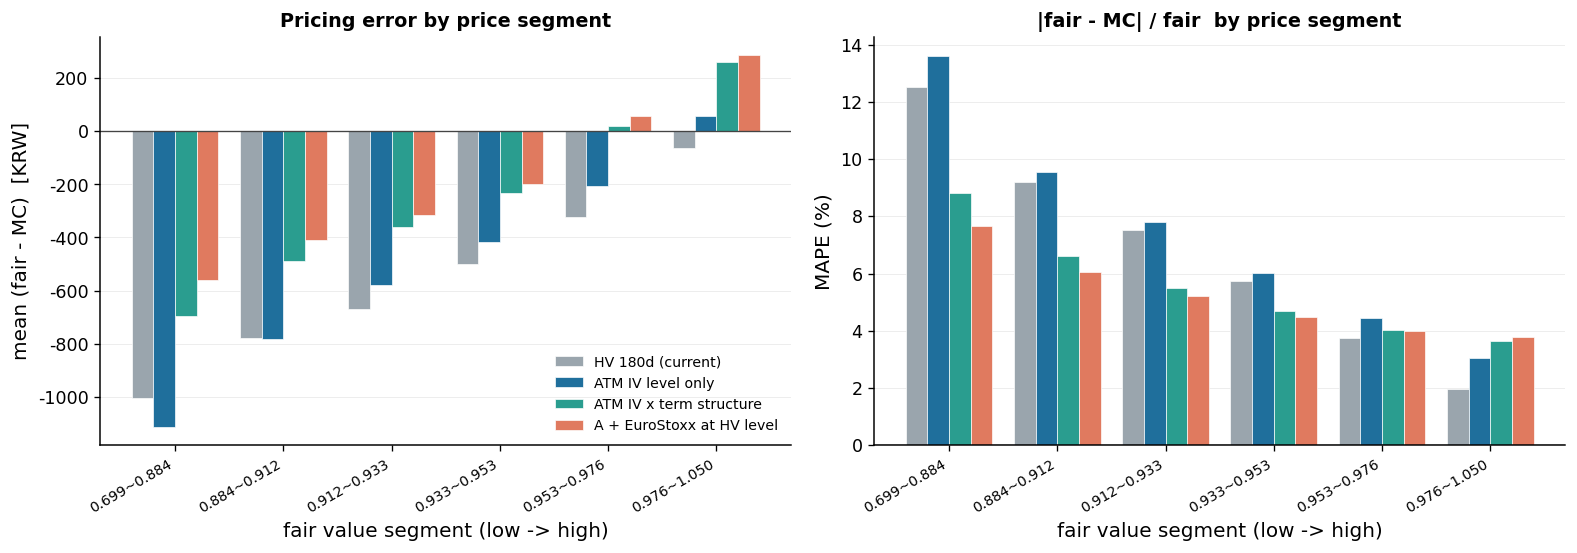

saved -> mc_ivts_by_price_seg.png


In [5]:
d["price_seg"] = pd.qcut(d.fair, 6)
rows = []
for seg, g in d.groupby("price_seg", observed=True):
    for v in VAR:
        e = g[f"err_{v}"]
        rows.append({"seg": f"{seg.left:.3f}~{seg.right:.3f}", "variant": v, "n": len(g),
                     "err_mean": e.mean(), "MAPE": (e.abs()/(g.fair*FACE)).mean()*100})
G = pd.DataFrame(rows)
G.to_csv(fm.stat("mc_ivts_by_price_seg"), index=False)
print(G.pivot(index="seg", columns="variant", values="err_mean")[VAR].round(0).to_string())
print()
print(G.pivot(index="seg", columns="variant", values="MAPE")[VAR].round(3).to_string())

segs = list(dict.fromkeys(G.seg)); x = np.arange(len(segs)); w = .2
fig, ax = plt.subplots(1, 2, figsize=(_plot.SLIDE_W, 4.8))
for j, v in enumerate(VAR):
    s = G[G.variant == v].set_index("seg").loc[segs]
    ax[0].bar(x + (j-1.5)*w, s.err_mean, w, label=LAB[v], color=COL[v], edgecolor="white", linewidth=.4)
    ax[1].bar(x + (j-1.5)*w, s.MAPE, w, label=LAB[v], color=COL[v], edgecolor="white", linewidth=.4)
for a, yl, tt in [(ax[0], "mean (fair - MC)  [KRW]", "Pricing error by price segment"),
                  (ax[1], "MAPE (%)", "|fair - MC| / fair  by price segment")]:
    a.set_xticks(x); a.set_xticklabels(segs, rotation=30, ha="right", fontsize=8.5)
    a.set_xlabel("fair value segment (low -> high)"); a.set_ylabel(yl); a.set_title(tt, fontsize=11.5)
    a.axhline(0, color="#444", lw=.8); a.grid(axis="y", color="#dddddd", lw=.5, alpha=.6)
ax[0].legend(fontsize=8.5, loc="lower right")
fig.tight_layout(); fig.savefig(fm.image("mc_ivts_by_price_seg")); plt.show()
print("saved ->", fm.image("mc_ivts_by_price_seg").name)

## 14-5. 어디서 줄었나 — 기초자산 · 구조 · 연도

유로스톡스 대용치가 결과를 지배하는지, 기간구조 효과가 특정 구조나 시기에 몰리는지 본다.


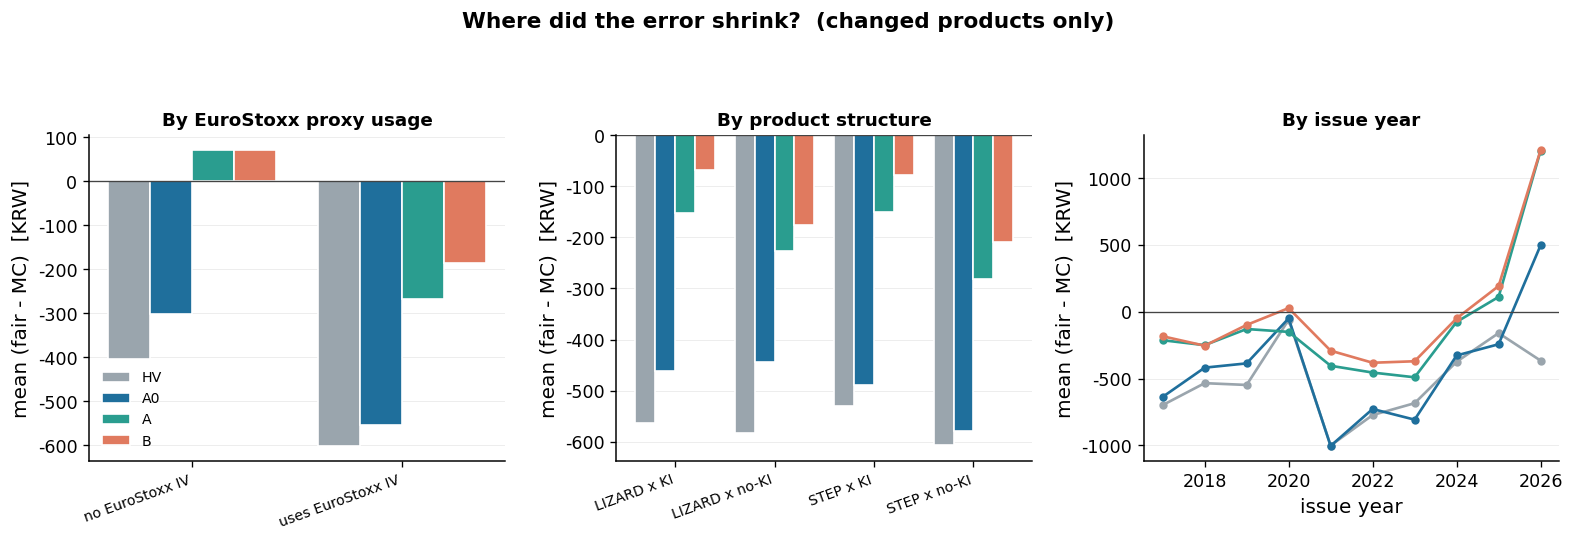

saved -> mc_ivts_where.png


In [6]:
d["struct"] = d.opt_type.astype(str) + " x " + np.where(d.ki_yn.astype(int) == 1, "KI", "no-KI")
d["sx5e_grp"] = np.where(d.sx5e_iv == 1, "uses EuroStoxx IV", "no EuroStoxx IV")
fig, axs = plt.subplots(1, 3, figsize=(_plot.SLIDE_W, 4.6))
for a, key, ttl in [(axs[0], "sx5e_grp", "By EuroStoxx proxy usage"),
                    (axs[1], "struct", "By product structure"),
                    (axs[2], "year", "By issue year")]:
    sub = d[d.changed]
    t = sub.groupby(key)[[f"err_{v}" for v in VAR]].mean()
    t.columns = VAR
    if key == "year":
        for v in VAR:
            a.plot(t.index, t[v], "o-", ms=4, lw=1.6, color=COL[v], label=v)
        a.set_xlabel("issue year")
    else:
        xx = np.arange(len(t)); ww = .2
        for j, v in enumerate(VAR):
            a.bar(xx + (j-1.5)*ww, t[v], ww, color=COL[v], label=v, edgecolor="white")
        a.set_xticks(xx); a.set_xticklabels(t.index, rotation=20, ha="right", fontsize=8.5)
    a.axhline(0, color="#444", lw=.8); a.set_ylabel("mean (fair - MC)  [KRW]")
    a.set_title(ttl, fontsize=11); a.grid(axis="y", color="#dddddd", lw=.5, alpha=.6)
axs[0].legend(fontsize=8.5)
fig.suptitle("Where did the error shrink?  (changed products only)", fontsize=13, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.92))
fig.savefig(fm.image("mc_ivts_where")); plt.show()
print("saved ->", fm.image("mc_ivts_where").name)